In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 32923 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:32923/status,
Dashboard: http://127.0.0.1:32923/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38243,Workers: 0
Dashboard: http://127.0.0.1:32923/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45685,Total threads: 8
Dashboard: http://127.0.0.1:44305/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:45707,


### Load MITgcm Output from Assimilations

In [2]:
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/TPOSE_TAO/OSM_2026/'

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [4]:
from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+31+28 # nov, dec, jan, feb (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

# ds_tpose_TAO = ds_tpose_TAO.chunk({
#     'XC': 200,   # horizontal cell-centered
#     'XG': 200,   # horizontal staggered
#     'YC': -1,    # single chunk along Y to speed up mean reductions
#     'YG': -1,    # same for staggered Y
#     'Z': 50 ,    # vertical levels
#     'time': -1,
#     })

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

In [5]:
lon_str = '170'

### Load TAO Data (T and S)

In [6]:
TAO_T_file = '/data/SO3/edavenport/TAO_2012to2016_daily/T_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_T = xr.open_dataset(TAO_T_file)
TAO_S_file = '/data/SO3/edavenport/TAO_2012to2016_daily/S_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_S = xr.open_dataset(TAO_S_file)
dsTAO = xr.merge([dsTAO_T,dsTAO_S])

/tmp/ipykernel_354013/391557641.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  dsTAO = xr.merge([dsTAO_T,dsTAO_S])


In [7]:
dsTAO['depth'] = -1*dsTAO.depth
dsTAO = dsTAO.sel(time=slice('2012-09-01','2013-03-01')) # subset to sep 2012, mar 2013
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XC'})

### Load TAO U and V

In [8]:
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO = xr.open_dataset(TAO_ADCP_file)

In [9]:
dsTAO['depth'] = -1*dsTAO.depth
dsTAO = dsTAO.sel(time=slice('2012-09-01','2013-03-01')) # subset to sep 2012, mar 2013
dsTAO['u_1205'] = dsTAO.u_1205/100 # convert from cm/s to m/s
dsTAO['v_1206'] = dsTAO.v_1206/100 # convert from cm/s to m/s

In [10]:
dsTAO

<xarray.Dataset> Size: 182kB
Dimensions:  (time: 182, depth: 62, lat: 1, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2012-09-01T12:00:00 ... 2013-03-01T12:...
  * depth    (depth) float32 248B -10.0 -15.0 -20.0 ... -305.0 -310.0 -315.0
  * lat      (lat) float32 4B 0.0
  * lon      (lon) float32 4B 190.0
Data variables:
    u_1205   (time, depth, lat, lon) float32 45kB nan nan nan ... nan nan nan
    QU_5205  (time, depth, lat, lon) float32 45kB ...
    v_1206   (time, depth, lat, lon) float32 45kB nan nan nan ... nan nan nan
    QV_5206  (time, depth, lat, lon) float32 45kB ...
Attributes:
    platform_code:                0n170w
    site_code:                    0n170w
    wmo_platform_code:            51010
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  Global Tropical Moored Buoy Array Project O...
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                09:58 14-AUG-2024

In [11]:
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XG'})
tpose_U_noTAO = ds_tpose_noTAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()
tpose_U_TAO = ds_tpose_TAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'XG':'XC','YC':'YG'})
tpose_V_noTAO = ds_tpose_noTAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()
tpose_V_TAO = ds_tpose_TAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()

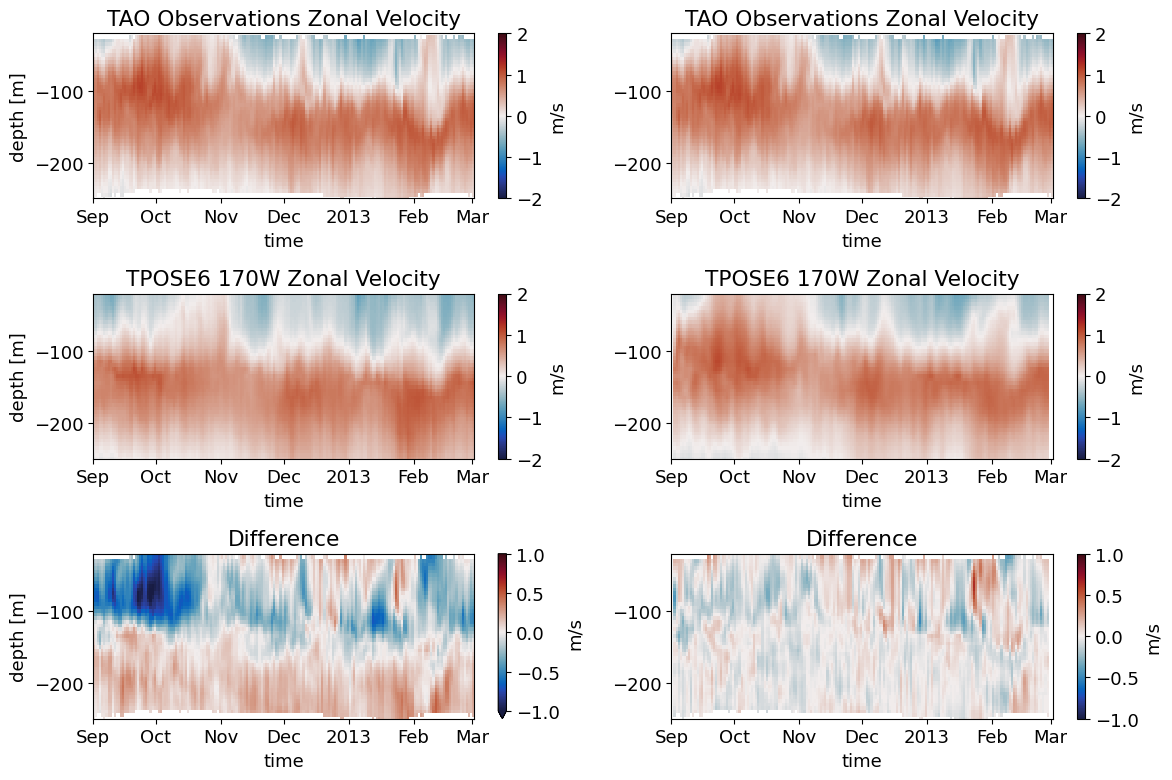

In [12]:
fig, ax = plt.subplots(figsize=(12,8),nrows=3,ncols=2)
dsTAO.u_1205.plot(ax=ax[0,0],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[0,0].set_title('TAO Observations Zonal Velocity')
ax[0,0].set_ylim(-250,-20)
tpose_U_noTAO.plot(ax=ax[1,0],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[1,0].set_title('TPOSE6 ' + lon_str + 'W Zonal Velocity')
ax[1,0].set_ylim(-250,-20)
(tpose_U_noTAO - dsTAO.u_1205).plot(ax=ax[2,0],cmap=cmo.balance,vmin=-1,vmax=1,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[2,0].set_title('Difference')
ax[2,0].set_ylim(-250,-20)

dsTAO.u_1205.plot(ax=ax[0,1],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[0,1].set_title('TAO Observations Zonal Velocity')
ax[0,1].set_ylabel('')
ax[0,1].set_ylim(-250,-20)
tpose_U_TAO.plot(ax=ax[1,1],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[1,1].set_title('TPOSE6 ' + lon_str + 'W Zonal Velocity')
ax[1,1].set_ylim(-250,-20)
ax[1,1].set_ylabel('')
(tpose_U_TAO - dsTAO.u_1205).plot(ax=ax[2,1],cmap=cmo.balance,vmin=-1,vmax=1,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[2,1].set_title('Difference')
ax[2,1].set_ylim(-250,-20)
ax[2,1].set_ylabel('')
plt.tight_layout()
fig.savefig(foldername+'U_' + lon_str + 'W_diffTAOassim.png')

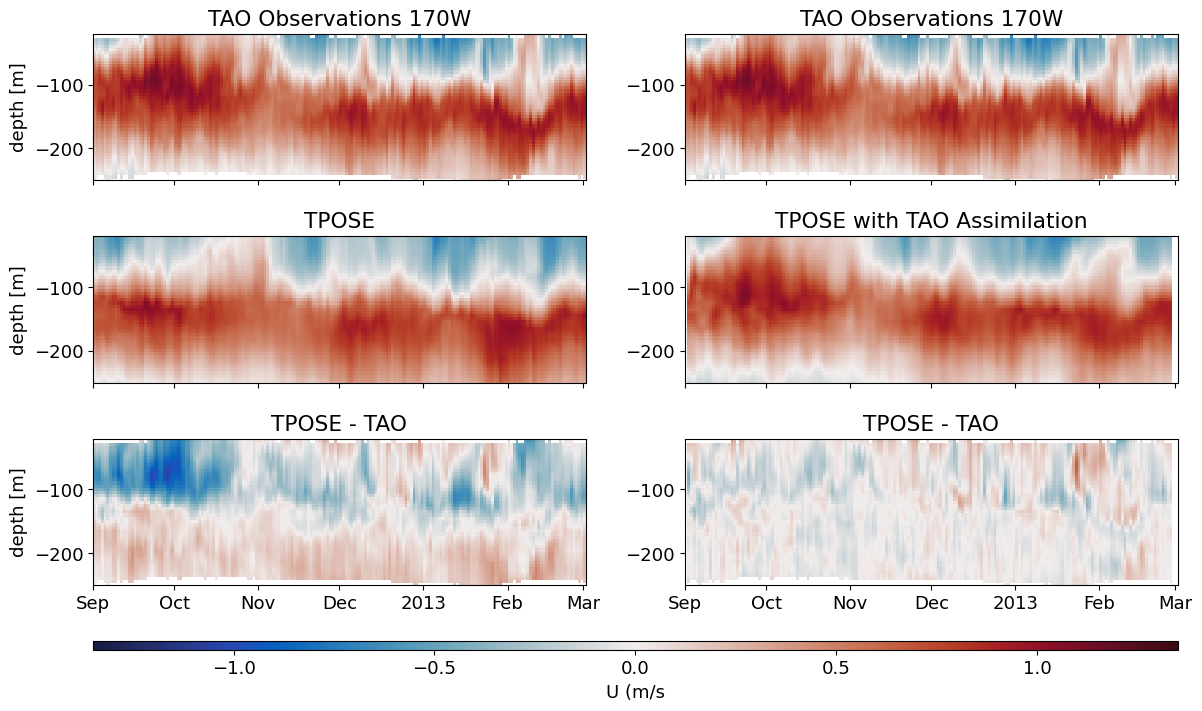

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 8))

gs = gridspec.GridSpec(
    4, 2,
    height_ratios=[1, 1, 1, 0.06],
    hspace=0.5,
    wspace=0.2
)

# Create axes with shared x within each column
ax = np.empty((3, 2), dtype=object)

ax[0,0] = fig.add_subplot(gs[0,0])
ax[1,0] = fig.add_subplot(gs[1,0], sharex=ax[0,0])
ax[2,0] = fig.add_subplot(gs[2,0], sharex=ax[0,0])

ax[0,1] = fig.add_subplot(gs[0,1])
ax[1,1] = fig.add_subplot(gs[1,1], sharex=ax[0,1])
ax[2,1] = fig.add_subplot(gs[2,1], sharex=ax[0,1])

vmin, vmax = -1.35, 1.35

# ----- Left column -----
mappable = dsTAO.u_1205.plot(
    ax=ax[0,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_U_noTAO.plot(
    ax=ax[1,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_U_noTAO - dsTAO.u_1205).plot(
    ax=ax[2,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- Right column -----
dsTAO.u_1205.plot(
    ax=ax[0,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_U_TAO.plot(
    ax=ax[1,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_U_TAO - dsTAO.u_1205).plot(
    ax=ax[2,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# Remove titles everywhere
for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(-250, -20)
        ax[i,j].set_xlabel('')

# Remove y-labels on right column
for i in range(3):
    ax[i,1].set_ylabel('')

# Remove x tick labels except bottom row
for j in range(2):
    ax[0,j].tick_params(labelbottom=False)
    ax[1,j].tick_params(labelbottom=False)

ax[0,0].set_title('TAO Observations ' + lon_str + 'W')
ax[1,0].set_title('TPOSE')
ax[2,0].set_title('TPOSE - TAO')
ax[0,1].set_title('TAO Observations ' + lon_str + 'W')
ax[1,1].set_title('TPOSE with TAO Assimilation')
ax[2,1].set_title('TPOSE - TAO')

# ----- Colorbar -----
cax = fig.add_subplot(gs[3, :])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('U (m/s')

fig.savefig(foldername+'U_' + lon_str + 'W_diffTAOassim_OSM.png')

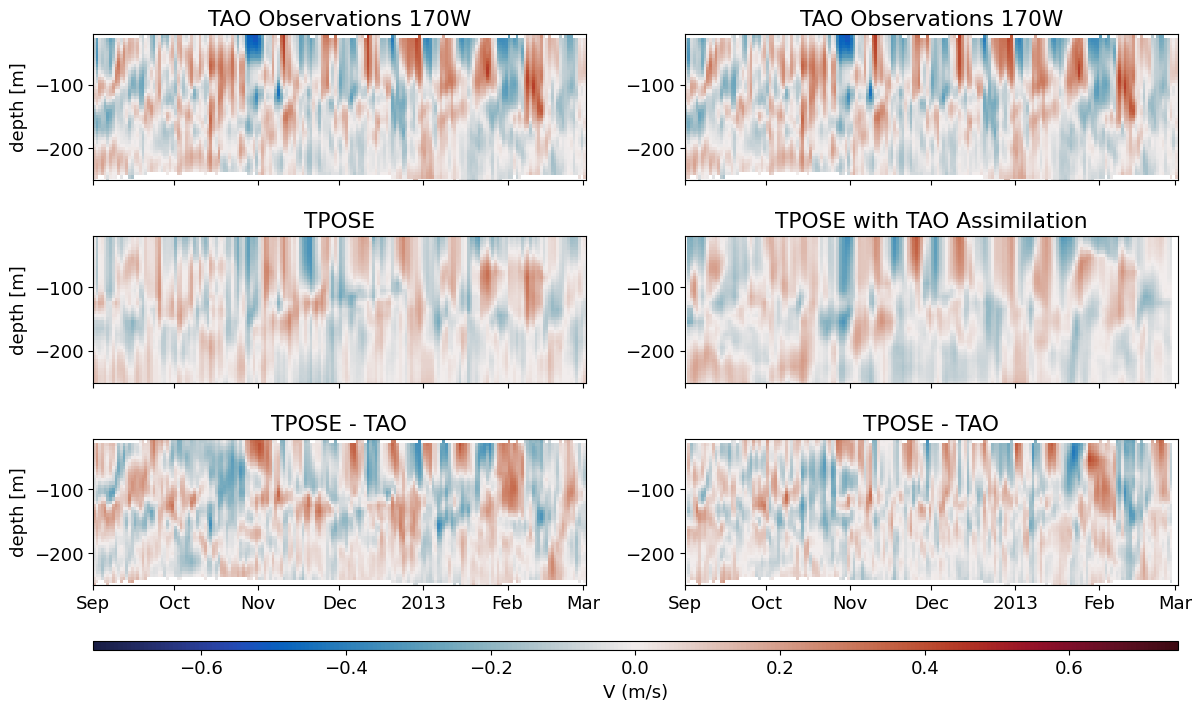

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 8))

gs = gridspec.GridSpec(
    4, 2,
    height_ratios=[1, 1, 1, 0.06],
    hspace=0.5,
    wspace=0.2
)

# Create axes with shared x within each column
ax = np.empty((3, 2), dtype=object)

ax[0,0] = fig.add_subplot(gs[0,0])
ax[1,0] = fig.add_subplot(gs[1,0], sharex=ax[0,0])
ax[2,0] = fig.add_subplot(gs[2,0], sharex=ax[0,0])

ax[0,1] = fig.add_subplot(gs[0,1])
ax[1,1] = fig.add_subplot(gs[1,1], sharex=ax[0,1])
ax[2,1] = fig.add_subplot(gs[2,1], sharex=ax[0,1])

vmin, vmax = -0.75, 0.75

# ----- Left column -----
mappable = dsTAO.v_1206.plot(
    ax=ax[0,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_V_noTAO.plot(
    ax=ax[1,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_V_noTAO - dsTAO.v_1206).plot(
    ax=ax[2,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- Right column -----
dsTAO.v_1206.plot(
    ax=ax[0,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_V_TAO.plot(
    ax=ax[1,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_V_TAO - dsTAO.v_1206).plot(
    ax=ax[2,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# Remove titles everywhere
for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(-250, -20)
        ax[i,j].set_xlabel('')

# Remove y-labels on right column
for i in range(3):
    ax[i,1].set_ylabel('')

# Remove x tick labels except bottom row
for j in range(2):
    ax[0,j].tick_params(labelbottom=False)
    ax[1,j].tick_params(labelbottom=False)

ax[0,0].set_title('TAO Observations ' + lon_str + 'W')
ax[1,0].set_title('TPOSE')
ax[2,0].set_title('TPOSE - TAO')
ax[0,1].set_title('TAO Observations ' + lon_str + 'W')
ax[1,1].set_title('TPOSE with TAO Assimilation')
ax[2,1].set_title('TPOSE - TAO')

# ----- Colorbar -----
cax = fig.add_subplot(gs[3, :])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('V (m/s)')

fig.savefig(foldername+'V_' + lon_str + 'W_diffTAOassim_OSM.png')


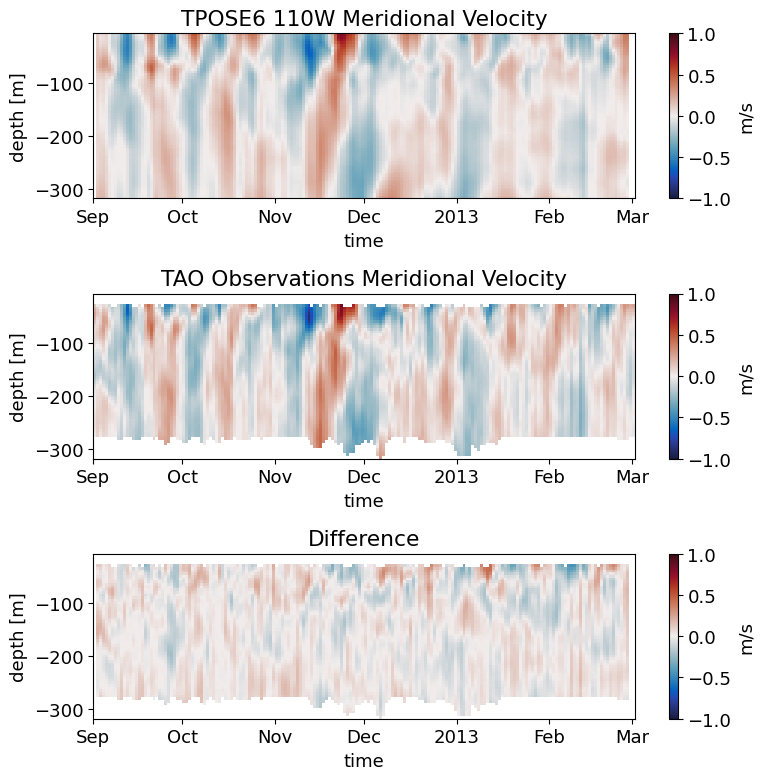

In [114]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,ncols=1)
tpose_V.plot(ax=ax[0],cmap=cmo.balance,vmin=-1.0,vmax=1.0,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[0].set_title('TPOSE6 ' + lon_str + 'W Meridional Velocity')
dsTAO.v_1206.plot(ax=ax[1],cmap=cmo.balance,vmin=-1.0,vmax=1.0,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[1].set_title('TAO Observations Meridional Velocity')
(tpose_V - dsTAO.v_1206).plot(ax=ax[2],cmap=cmo.balance,vmin=-1.0,vmax=1.0,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[2].set_title('Difference')
plt.tight_layout()
fig.savefig(foldername+'V_' + lon_str + 'W.png')

In [77]:
client.shutdown()
cluster.close()
client.close()